## 1. Consumo di alcol per paese

In [11]:
%conda install pandas
%conda install numpy
%conda install matplotlib

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest 

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame
df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


1. Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

In [104]:
df.sort_values(by='total_litres_of_pure_alcohol', ascending=False).head(10)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
15,Belarus,142,373,42,14.4
98,Lithuania,343,244,56,12.9
3,Andorra,245,138,312,12.4
68,Grenada,199,438,28,11.9
61,France,127,151,370,11.8
45,Czech Republic,361,170,134,11.8
141,Russian Federation,247,326,73,11.5
99,Luxembourg,236,133,271,11.4
155,Slovakia,196,293,116,11.4
81,Ireland,313,118,165,11.4


2. Calcola la media del consumo di birra, vino, e distillati

In [105]:
# Consumo di birra medio
df['beer_servings'].mean()

np.float64(106.16062176165804)

In [106]:
# Consumo di vino medio
df['wine_servings'].mean()

np.float64(49.45077720207254)

In [107]:
# Consumo di distillati medio
df['spirit_servings'].mean()

np.float64(80.99481865284974)

3. Crea una nuova colonna alcohol_index che sia: (beer_servings + wine_servings + spirit_servings) / 3

In [108]:
df['alcol_index'] = (df['beer_servings'] + df['spirit_servings'] + df['wine_servings']) / 3
df['alcol_index']

0        0.000000
1       91.666667
2       13.000000
3      231.666667
4      106.333333
          ...    
188    145.333333
189     38.000000
190      2.000000
191     18.333333
192     28.666667
Name: alcol_index, Length: 193, dtype: float64

4. Trova il paese con il valore massimo di alcohol_index

In [109]:
df.sort_values(by='alcol_index', ascending=False).head(1)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcol_index
3,Andorra,245,138,312,12.4,231.666667


5. Filtra solo i paesi che consumano più di 100 birre all’anno

In [110]:
df[df['beer_servings'] > 100]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcol_index
3,Andorra,245,138,312,12.4,231.666667
4,Angola,217,57,45,5.9,106.333333
5,Antigua & Barbuda,102,128,45,4.9,91.666667
6,Argentina,193,25,221,8.3,146.333333
8,Australia,261,72,212,10.4,181.666667
...,...,...,...,...,...,...
182,United Kingdom,219,126,195,10.4,180.000000
184,USA,249,158,84,8.7,163.666667
185,Uruguay,115,35,220,6.6,123.333333
188,Venezuela,333,100,3,7.7,145.333333


6. Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

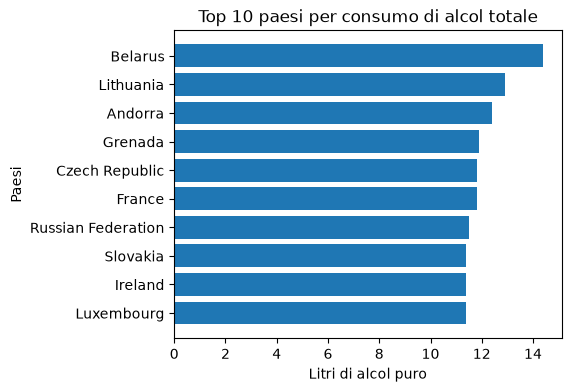

In [ ]:
# Ordino per consumo e prendo i primi dieci paesi
most_liters_of_pure_alcohol = df.sort_values(by='total_litres_of_pure_alcohol', ascending=True).tail(10)

plt.figure(figsize=(5, 4))
plt.barh(most_liters_of_pure_alcohol.country, most_liters_of_pure_alcohol.total_litres_of_pure_alcohol)
plt.title('Top 10 paesi per consumo di alcol totale')
plt.xlabel('Litri di alcol puro')
plt.ylabel('Paesi')
plt.show()

7. Crea un line plot con wine_servings ordinato per paese (usa sort_values)

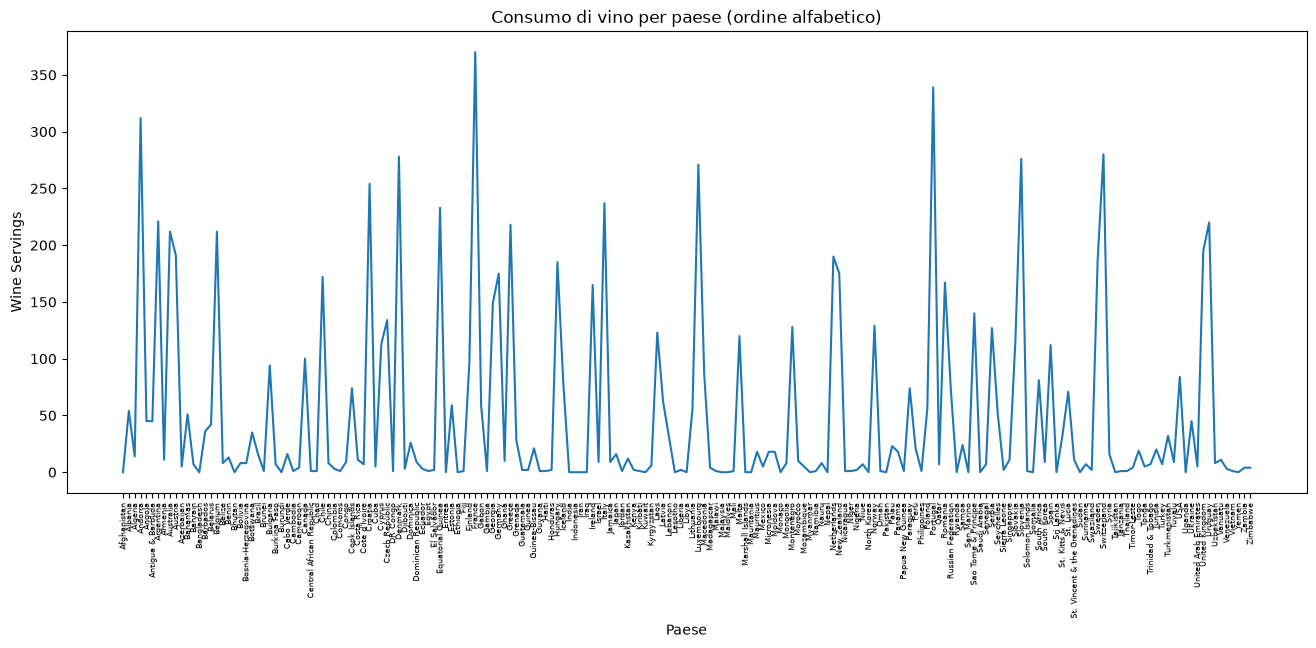

In [ ]:
df_sorted_by_country = df.sort_values('country')

plt.figure(figsize=(16, 6))
plt.plot(df_sorted_by_country['country'], df_sorted_by_country['wine_servings'])
plt.title('Consumo di vino per paese (ordine alfabetico)')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel('Paese')
plt.ylabel('Wine Servings')
plt.show()